In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(df.shape)

print(df.columns)

df.info()

df.describe()

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [5]:
print("Duplicate Rows :",df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows : 0


In [6]:
df.dtypes

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

In [7]:
df.describe(include='all')

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


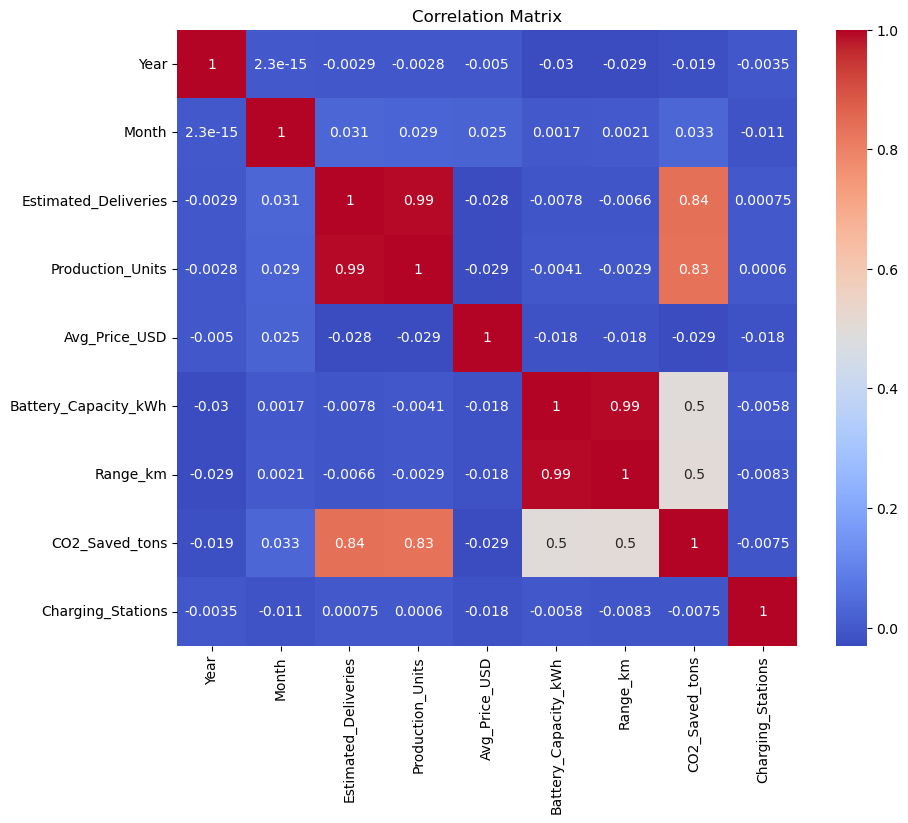

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

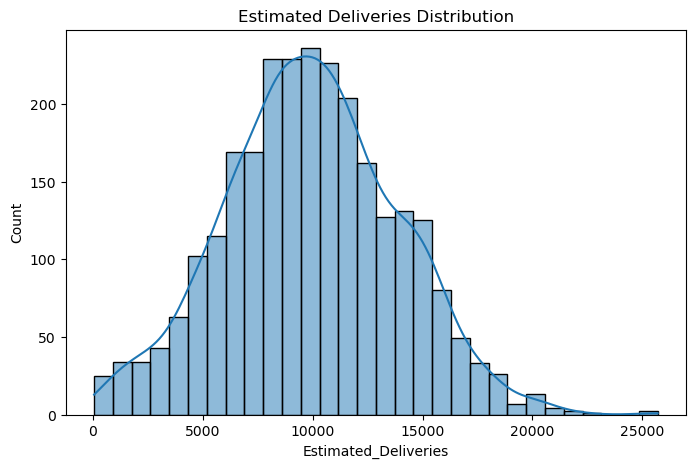

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Estimated_Deliveries"],
             bins=30,
             kde=True)

plt.title("Estimated Deliveries Distribution")

plt.show()

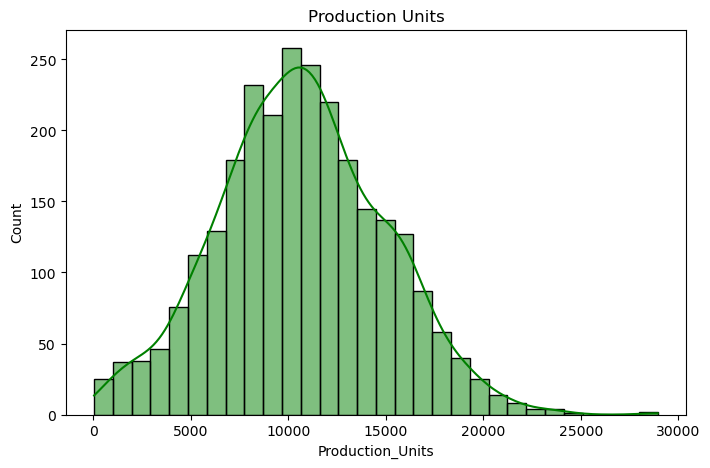

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["Production_Units"],
             bins=30,
             color="green",
             kde=True)

plt.title("Production Units")

plt.show()

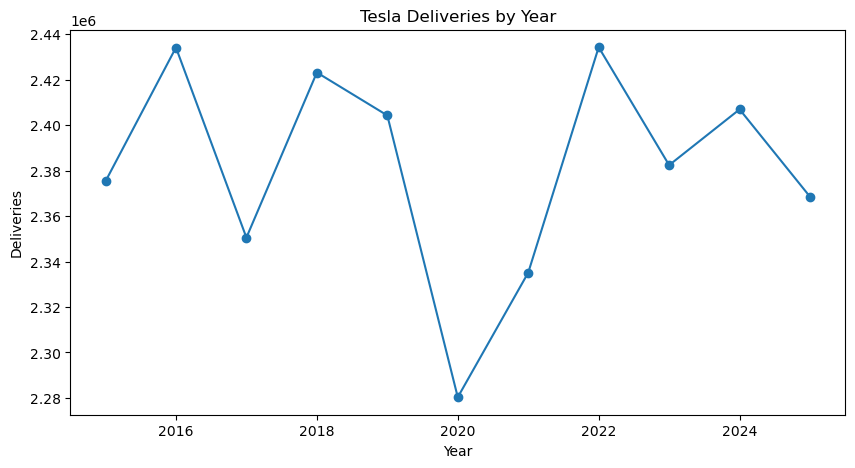

In [11]:
year_delivery = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))

year_delivery.plot(marker='o')

plt.title("Tesla Deliveries by Year")

plt.ylabel("Deliveries")

plt.show()

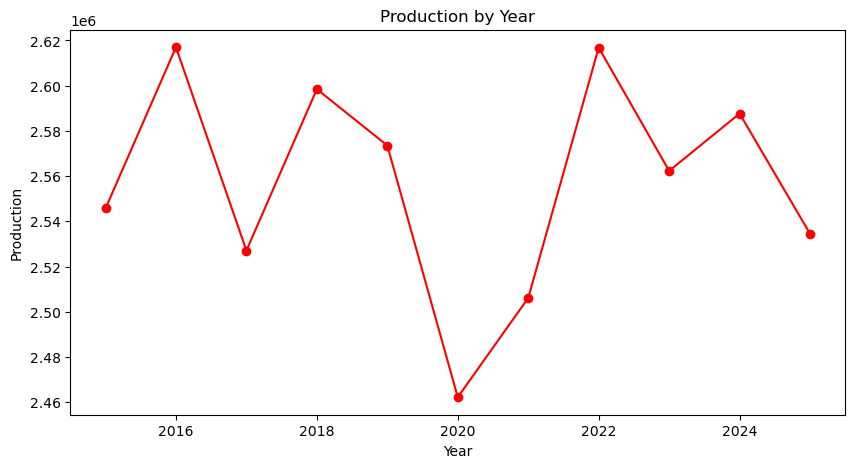

In [12]:
year_prod = df.groupby("Year")["Production_Units"].sum()

plt.figure(figsize=(10,5))

year_prod.plot(marker='o',
               color='red')

plt.title("Production by Year")

plt.ylabel("Production")

plt.show()

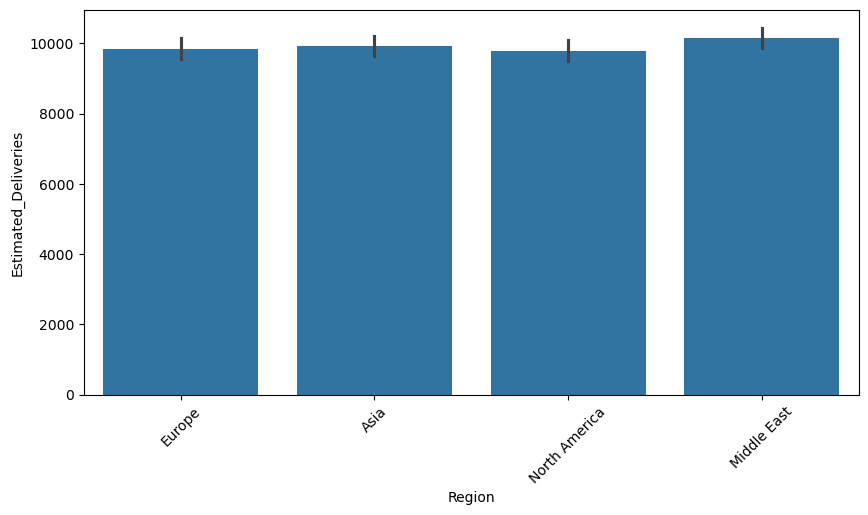

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(data=df,
            x="Region",
            y="Estimated_Deliveries",
            estimator=np.mean)

plt.xticks(rotation=45)

plt.show()

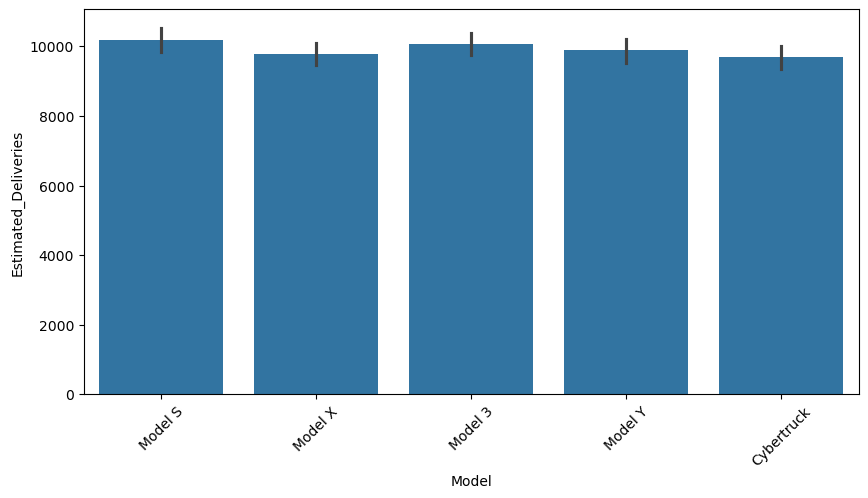

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(data=df,
            x="Model",
            y="Estimated_Deliveries",
            estimator=np.mean)

plt.xticks(rotation=45)

plt.show()

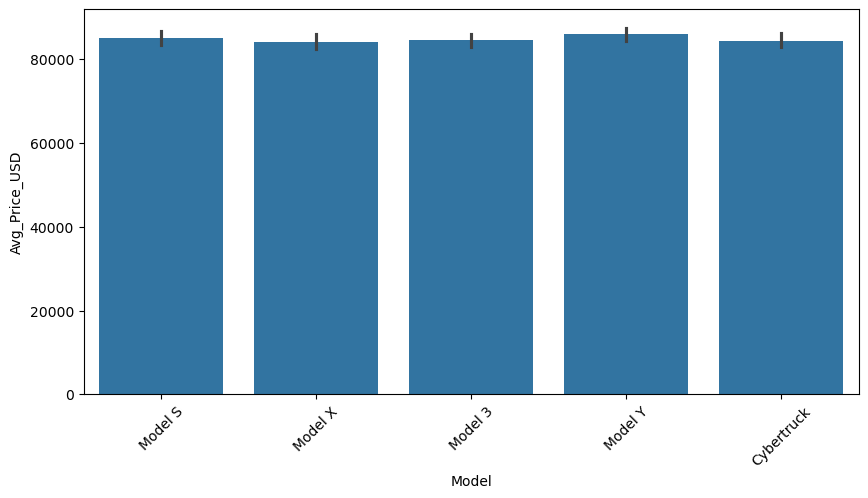

In [15]:
plt.figure(figsize=(10,5))

sns.barplot(data=df,
            x="Model",
            y="Avg_Price_USD")

plt.xticks(rotation=45)

plt.show()

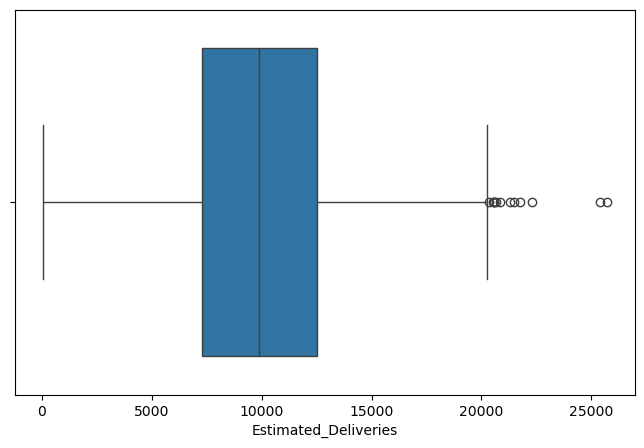

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Estimated_Deliveries"])

plt.show()

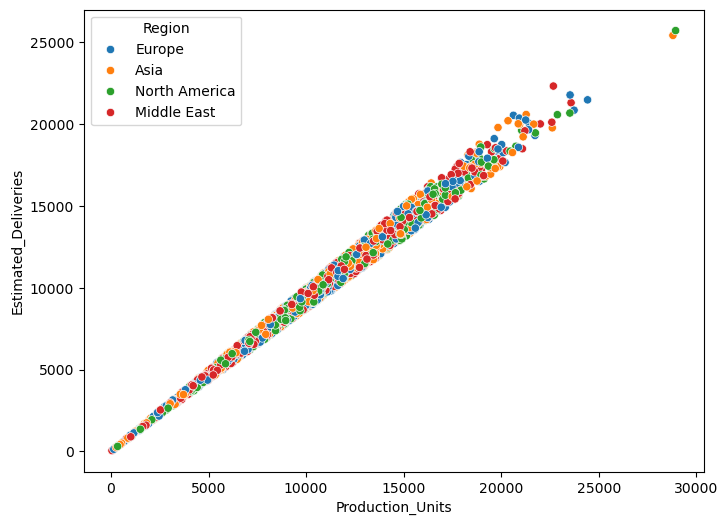

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries",
    hue="Region"
)

plt.show()

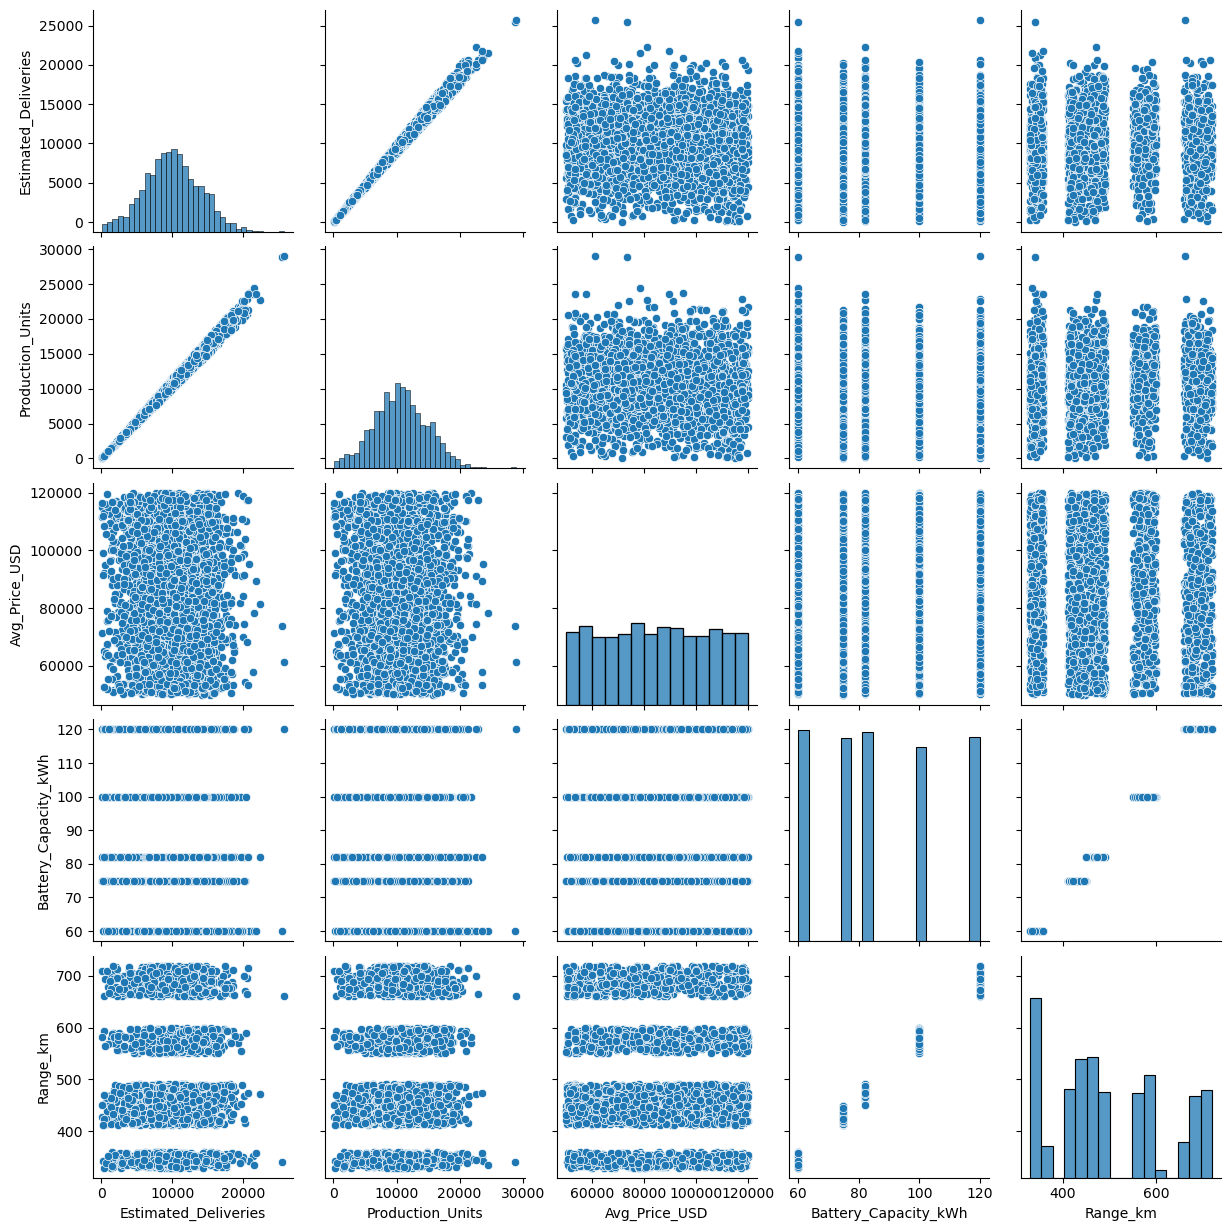

In [18]:
sns.pairplot(
    df[
        [
            "Estimated_Deliveries",
            "Production_Units",
            "Avg_Price_USD",
            "Battery_Capacity_kWh",
            "Range_km"
        ]
    ]
)

plt.show()

In [19]:
df["Delivery_Production_Ratio"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

df["Price_per_kWh"] = (
    df["Avg_Price_USD"] /
    df["Battery_Capacity_kWh"]
)

df["CO2_per_Delivery"] = (
    df["CO2_Saved_tons"] /
    df["Estimated_Deliveries"]
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Production_Ratio,Price_per_kWh,CO2_per_Delivery
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,773.952250,0.105600
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,829.408667,0.065699
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,1437.650244,0.072000
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,744.124250,0.106799
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,957.056500,0.099150


In [20]:
encoder = LabelEncoder()

df["Region"] = encoder.fit_transform(df["Region"])

df["Model"] = encoder.fit_transform(df["Model"])

df["Source_Type"] = encoder.fit_transform(df["Source_Type"])

In [21]:
X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, y_pred_lr))
print("MSE :", mean_squared_error(y_test, y_pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score :", r2_score(y_test, y_pred_lr))

Linear Regression
MAE : 108.80891613963428
MSE : 23477.25733230339
RMSE : 153.2229008089306
R2 Score : 0.9984250098266227


In [25]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")

print("MAE :", mean_absolute_error(y_test, y_pred_dt))
print("MSE :", mean_squared_error(y_test, y_pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score :", r2_score(y_test, y_pred_dt))

Decision Tree
MAE : 114.44318181818181
MSE : 25006.621212121212
RMSE : 158.1348197334199
R2 Score : 0.9983224112543901


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")

print("MAE :", mean_absolute_error(y_test, y_pred_rf))
print("MSE :", mean_squared_error(y_test, y_pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score :", r2_score(y_test, y_pred_rf))

Random Forest
MAE : 67.45624999999998
MSE : 12497.482039393944
RMSE : 111.79213764569468
R2 Score : 0.9991615966411493


In [27]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [28]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_estimators=100
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost")

print("MAE :", mean_absolute_error(y_test, y_pred_xgb))
print("MSE :", mean_squared_error(y_test, y_pred_xgb))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("R2 Score :", r2_score(y_test, y_pred_xgb))

XGBoost
MAE : 72.81684875488281
MSE : 11089.833984375
RMSE : 105.308280701828
R2 Score : 0.9992560148239136


In [29]:
param_grid = {

    'n_estimators':[100,200,300],

    'max_depth':[5,10,15,None],

    'min_samples_split':[2,5,10]

}

grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1

)

grid.fit(X_train,y_train)

print("Best Parameters")

print(grid.best_params_)

best_rf = grid.best_estimator_

Best Parameters
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [30]:
y_pred_best = best_rf.predict(X_test)

In [31]:
mae = mean_absolute_error(y_test,y_pred_best)

mse = mean_squared_error(y_test,y_pred_best)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,y_pred_best)

print("MAE :",mae)

print("MSE :",mse)

print("RMSE :",rmse)

print("R2 :",r2)

MAE : 68.18545612549802
MSE : 13412.792424583271
RMSE : 115.81361070523305
R2 : 0.9991001923279513


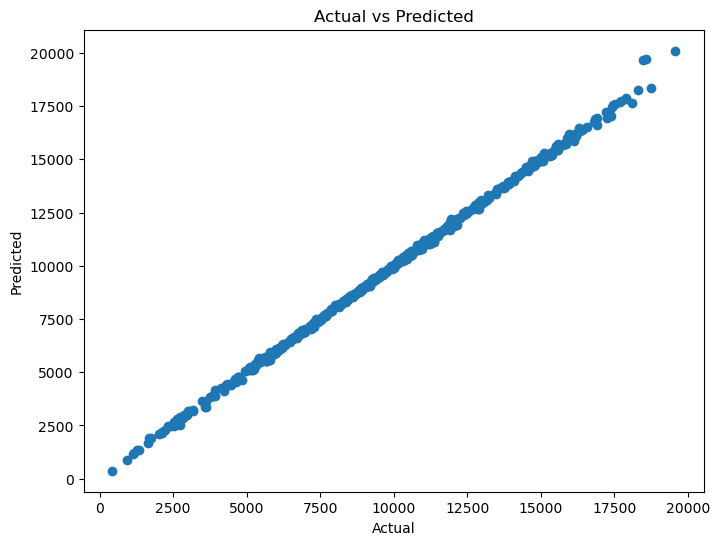

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,y_pred_best)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

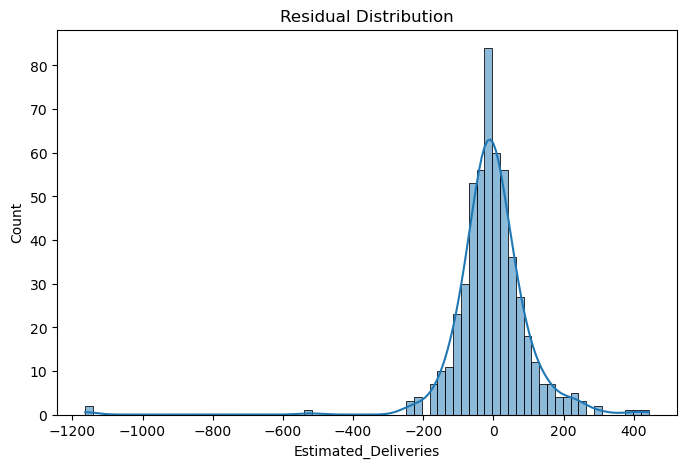

In [33]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8,5))

sns.histplot(residuals,kde=True)

plt.title("Residual Distribution")

plt.show()

In [34]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
4,Production_Units,0.990438
11,Delivery_Production_Ratio,0.008647
8,CO2_Saved_tons,0.000197
12,Price_per_kWh,0.000127
5,Avg_Price_USD,0.000100
10,Charging_Stations,0.000078
1,Month,0.000075
0,Year,0.000068
7,Range_km,0.000067
13,CO2_per_Delivery,0.000063


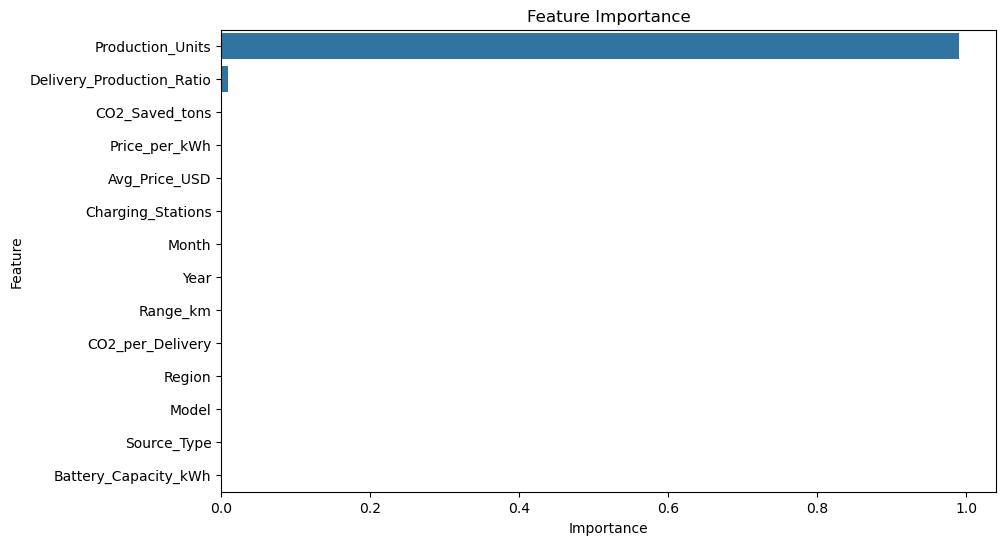

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title("Feature Importance")

plt.show()

In [36]:
comparison = pd.DataFrame({

"Model":[

"Linear Regression",

"Decision Tree",

"Random Forest",

"XGBoost"

],

"MAE":[

mean_absolute_error(y_test,y_pred_lr),

mean_absolute_error(y_test,y_pred_dt),

mean_absolute_error(y_test,y_pred_rf),

mean_absolute_error(y_test,y_pred_xgb)

],

"RMSE":[

np.sqrt(mean_squared_error(y_test,y_pred_lr)),

np.sqrt(mean_squared_error(y_test,y_pred_dt)),

np.sqrt(mean_squared_error(y_test,y_pred_rf)),

np.sqrt(mean_squared_error(y_test,y_pred_xgb))

],

"R2":[

r2_score(y_test,y_pred_lr),

r2_score(y_test,y_pred_dt),

r2_score(y_test,y_pred_rf),

r2_score(y_test,y_pred_xgb)

]

})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,108.808916,153.222901,0.998425
1,Decision Tree,114.443182,158.134820,0.998322
2,Random Forest,67.456250,111.792138,0.999162
3,XGBoost,72.816849,105.308281,0.999256


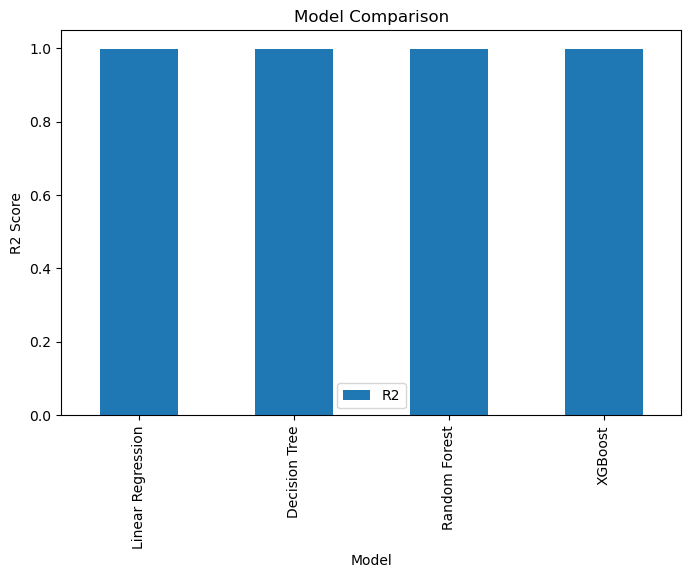

In [37]:
comparison.plot(

x="Model",

y="R2",

kind="bar",

figsize=(8,5)

)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

In [38]:
df["Date"] = pd.to_datetime(

dict(

year=df.Year,

month=df.Month,

day=1

)

)

In [39]:
ts = df.groupby("Date")["Estimated_Deliveries"].sum()

ts.head()

Date
2015-01-01    183180
2015-02-01    165053
2015-03-01    184567
2015-04-01    225623
2015-05-01    184264
Name: Estimated_Deliveries, dtype: int64

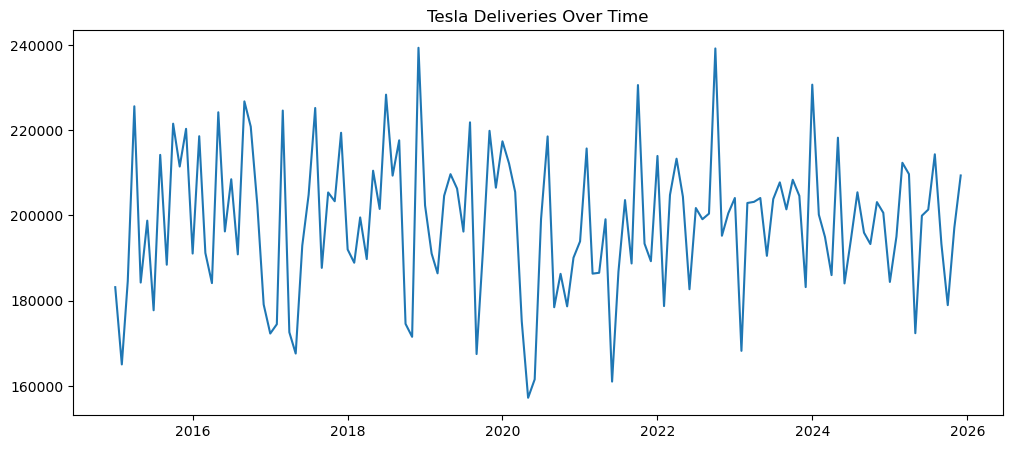

In [40]:
plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title("Tesla Deliveries Over Time")

plt.show()

In [41]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts,order=(2,1,2))

model_fit = model.fit()

forecast = model_fit.forecast(12)

forecast

/opt/anaconda3/envs/kaggle_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/kaggle_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/kaggle_env/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2026-01-01    201434.637504
2026-02-01    200328.856460
2026-03-01    199801.924393
2026-04-01    199648.939958
2026-05-01    199597.002292
2026-06-01    199580.316085
2026-07-01    199574.853402
2026-08-01    199573.076624
2026-09-01    199572.497422
2026-10-01    199572.308756
2026-11-01    199572.247285
2026-12-01    199572.227259
Freq: MS, Name: predicted_mean, dtype: float64

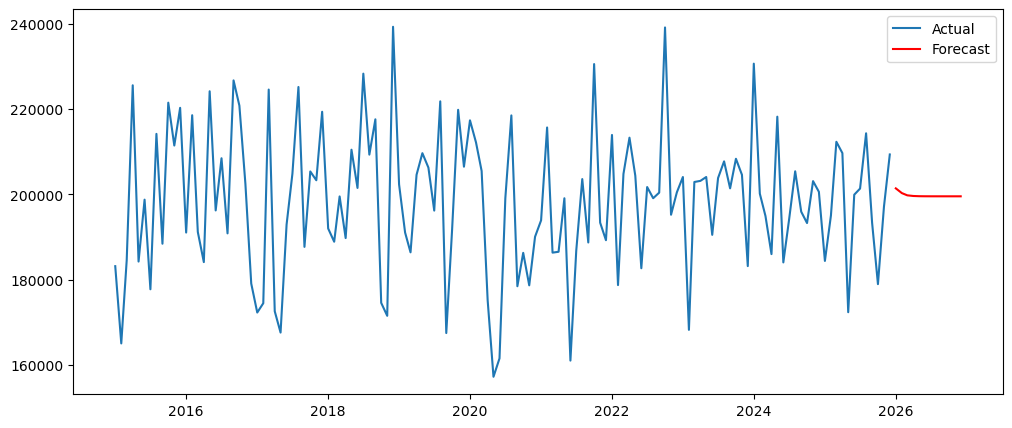

In [42]:
plt.figure(figsize=(12,5))

plt.plot(ts,label="Actual")

plt.plot(

forecast.index,

forecast.values,

label="Forecast",

color="red"

)

plt.legend()

plt.show()

In [43]:
print("Highest Deliveries Year")

print(df.groupby("Year")["Estimated_Deliveries"].sum().idxmax())

print()

print("Highest Production Year")

print(df.groupby("Year")["Production_Units"].sum().idxmax())

print()

print("Highest Revenue Model")

print(df.groupby("Model")["Avg_Price_USD"].mean().idxmax())

print()

print("Highest Delivery Region")

print(df.groupby("Region")["Estimated_Deliveries"].sum().idxmax())

Highest Deliveries Year
2022

Highest Production Year
2016

Highest Revenue Model
4

Highest Delivery Region
2


In [44]:
import joblib

joblib.dump(best_rf,"tesla_model.pkl")

['tesla_model.pkl']

In [45]:
import joblib

joblib.dump(best_rf,"tesla_model.pkl")

['tesla_model.pkl']